In [1]:
import numpy as np

def compute_fitness(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    PFM = np.zeros((4, motif_length)) # 4 rows are A, T, G, C
    for motif in motifs:
        for col, char in enumerate(motif):
            if char == "A":
                PFM[0, col] += 1
            elif char == "T":
                PFM[1, col] += 1
            elif char == "C":
                PFM[2, col] += 1
            elif char == "G":
                PFM[3, col] += 1
    score = 0
    for col in range(motif_length):
        score += max(PFM[:, col])
    return score

In [2]:
import random
random.seed(42)
np.random.seed(42)

def initialize_population(pop_size, sequences, motif_length):
    population = [[random.randint(0, len(seq) - motif_length) for seq in sequences] for _ in range(pop_size)]
    return population

In [3]:
def tournament_select(population, fitnesses, tournament_size):
    rand_selected_pop = random.sample(range(len(population)), tournament_size)
    winner_index = max(rand_selected_pop, key=lambda i: fitnesses[i])
    return population[winner_index]

In [4]:
seq = ["ACATCGGAT", "ATGCATAAG", "TACCCGCAT"]
chr = [2, 3, 2]
print(compute_fitness(chr, seq, 3))

population = initialize_population(5, seq, 3)
print(population)

5.0
[[5, 0, 0], [5, 2, 1], [1, 1, 5], [0, 5, 5], [4, 0, 4]]


In [5]:
def crossover(parent_a, parent_b):
    cut = random.randint(1, len(parent_a) - 1)
    child = parent_a[:cut] + parent_b[cut:]
    return child

In [6]:
parent_a = [42, 17, 305, 88, 21]
parent_b = [10, 99,  14, 200, 55]
print(crossover(parent_a, parent_b))

[42, 17, 305, 88, 55]


In [7]:
def mutate(chromosome, sequences, motif_length, mutation_rate):
    new_chromosome = chromosome[:]
    for i, seq in enumerate(sequences):
        if random.random() < mutation_rate:
            new_chromosome[i] = random.randint(0, len(seq) - motif_length)
    return new_chromosome

In [9]:
def run_ga(population, sequences, motif_length, num_generations, tournament_size, mutation_rate, elite_count):
    best_chromosome = None
    best_fitness = 0
    
    for gen in range(num_generations):
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:elite_count]
        elites = [population[i] for i in elite_indices]
        new_population = elites[:]
        while len(new_population) != len(population):
            parent_a = tournament_select(population, fitnesses, tournament_size)
            parent_b = tournament_select(population, fitnesses, tournament_size)
            child = crossover(parent_a, parent_b)
            mutated_child = mutate(child, sequences, motif_length, mutation_rate)
            new_population.append(mutated_child)
        
        population = new_population
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        gen_best_index = fitnesses.index(max(fitnesses))
        if fitnesses[gen_best_index] > best_fitness:
            best_fitness = fitnesses[gen_best_index]
            best_chromosome = population[gen_best_index]
    
    return best_chromosome, best_fitness

In [8]:
def write_to_txt (string, filename):
    with open(filename, "a") as f:
        f.write(string + "\n")
def read_txt_and_return_lines(filename):
    with open(filename, "r") as f:
        lines = [line.strip() for line in f]
    return lines

In [12]:
sequences = read_txt_and_return_lines("9_char_seq.txt") 

POP_SIZE = 200
NUM_GENERATIONS = 1000
TOURNAMENT_SIZE = 3
MUTATION_RATE = 0.01
ELITE_COUNT = 5
MOTIF_LENGTH = 9

population = initialize_population(POP_SIZE, sequences, MOTIF_LENGTH)
best_chromosome, best_fitness = run_ga(population, sequences, MOTIF_LENGTH, NUM_GENERATIONS, TOURNAMENT_SIZE, MUTATION_RATE, ELITE_COUNT)

print(f"Best fitness: {best_fitness}/180")
print(f"Best chromosome: {best_chromosome}")

best_motifs = [seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, best_chromosome)]
for motif in best_motifs:
    print(motif)
print(f"Recovered motif: {best_motifs[0]}")  # they should all be similar

nine_char_motif = read_txt_and_return_lines("motifs.txt")[0]
print(f"Actual motif: {nine_char_motif}")



Best fitness: 139.0/180
Best chromosome: [26, 47, 70, 69, 69, 12, 4, 50, 9, 76, 43, 4, 6, 43, 36, 64, 6, 20, 29, 53]
TATTAATGA
TGATTTTGA
TATTTTACA
TGCTTTTGA
CATTTTTGA
CGGTTTTGA
GCGTTTTGA
ATCTTTTGA
TGATTTTGA
TCCTTTTGA
TGCTTTTGA
GTTTTTTGA
TAGTTTTGA
TATCTTTAA
CACTTTTGA
TCATTTTGA
GATTTTTGA
TATTTTGAA
TGCTTTTGA
CGATTTTGA
Recovered motif: TATTAATGA
Actual motif: TTTTGAAGT


In [9]:
import matplotlib.pyplot as plt

def run_ga_with_history(population, sequences, motif_length, num_generations, tournament_size, mutation_rate, elite_count):
    best_chromosome = None
    best_fitness = 0
    
    history = {
        "best": [],
        "avg": [],
        "worst": []
    }
    
    for gen in range(num_generations):
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        # Track stats before selection
        history["best"].append(max(fitnesses))
        history["avg"].append(sum(fitnesses) / len(fitnesses))
        history["worst"].append(min(fitnesses))
        
        elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:elite_count]
        elites = [population[i] for i in elite_indices]
        new_population = elites[:]
        
        while len(new_population) != len(population):
            parent_a = tournament_select(population, fitnesses, tournament_size)
            parent_b = tournament_select(population, fitnesses, tournament_size)
            child = crossover(parent_a, parent_b)
            mutated_child = mutate(child, sequences, motif_length, mutation_rate)
            new_population.append(mutated_child)
        
        population = new_population
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        gen_best_index = fitnesses.index(max(fitnesses))
        if fitnesses[gen_best_index] > best_fitness:
            best_fitness = fitnesses[gen_best_index]
            best_chromosome = population[gen_best_index]
    
    return best_chromosome, best_fitness, history


def plot_convergence(history, motif_length, num_generations, save_path=None):
    max_possible = motif_length * 20  # 20 sequences → adjust if different

    generations = list(range(1, num_generations + 1))

    plt.figure(figsize=(10, 5))
    plt.plot(generations, history["best"],  label="Best Fitness",  color="royalblue",  linewidth=2)
    plt.plot(generations, history["avg"],   label="Avg Fitness",   color="darkorange", linewidth=1.5, linestyle="--")
    plt.plot(generations, history["worst"], label="Worst Fitness", color="tomato",     linewidth=1,   linestyle=":")

    plt.axhline(y=max_possible, color="green", linestyle="--", linewidth=1, label=f"Max Possible ({max_possible})")

    plt.xlabel("Generation")
    plt.ylabel("Fitness Score")
    plt.title(f"GA Convergence — Motif Length {motif_length}")
    plt.legend()
    plt.tight_layout()
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()

In [37]:
from itertools import product

pop_sizes = [50, 100, 200, 300]
num_generations = [250, 500, 1000]
tournament_sizes = [2, 3, 5]
mutation_rates = [0.01, 0.02, 0.05, 0.075]
elite_counts = [1, 2, 5, 10]

best_params = None
best_result = 0

for pop, gen, tour, mut, elite in product(pop_sizes, num_generations, tournament_sizes, mutation_rates, elite_counts):
    random.seed(42)
    np.random.seed(42)
    population = initialize_population(pop, sequences, MOTIF_LENGTH)
    chromosome, fitness = run_ga(population, sequences, MOTIF_LENGTH, gen, tour, mut, elite)
    recovered_motifs = [seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, chromosome)]
    print(f"pop={pop}, gen={gen}, tour={tour}, mut={mut}, elite={elite} → fitness={fitness}")
    print(f"Recovered: {recovered_motifs[0]} | Actual: {nine_char_motif}")
    print("---")
    if fitness > best_result:
        best_result = fitness
        best_params = (pop, gen, tour, mut, elite)
        best_chromosome = chromosome

print(f"\nBest params: {best_params} → fitness={best_result}")
print(f"Best recovered motif: {[seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, best_chromosome)][0]}")
print(f"Actual motif: {nine_char_motif}")

pop=50, gen=250, tour=2, mut=0.01, elite=1 → fitness=160.0
Recovered: GTTTTGAAG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.01, elite=2 → fitness=121.0
Recovered: TTGAAACAA | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.01, elite=5 → fitness=116.0
Recovered: ACGCATTAG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.01, elite=10 → fitness=111.0
Recovered: CTAGAGTGC | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.02, elite=1 → fitness=117.0
Recovered: GCTAGAATG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.02, elite=2 → fitness=116.0
Recovered: AATGAGTCG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.02, elite=5 → fitness=113.0
Recovered: GCTAGAATG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.02, elite=10 → fitness=114.0
Recovered: TCTAGAGTG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.05, elite=1 → fitness=113.0
Recovered: TCTAGAGTG | Actual: TTTTGAAGT
---
pop=50, gen=250, tour=2, mut=0.05, elite=2 → fitness=116.0
Rec

In [10]:
sequences = read_txt_and_return_lines("9_char_seq.txt") 

POP_SIZE = 300
NUM_GENERATIONS = 250
TOURNAMENT_SIZE = 2
MUTATION_RATE = 0.3
ELITE_COUNT = 2
MOTIF_LENGTH = 9

population = initialize_population(POP_SIZE, sequences, MOTIF_LENGTH)
best_chromosome, best_fitness, history = run_ga_with_history(
    population, sequences, MOTIF_LENGTH, NUM_GENERATIONS,
    TOURNAMENT_SIZE, MUTATION_RATE, ELITE_COUNT
)

print(f"Best fitness: {best_fitness}/{MOTIF_LENGTH * 20}")
print(f"Best chromosome: {best_chromosome}")

best_motifs = [seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, best_chromosome)]
for motif in best_motifs:
    print(motif)

plot_convergence(history, MOTIF_LENGTH, NUM_GENERATIONS, save_path="convergence.png")

KeyboardInterrupt: 

In [11]:
def extract_perfect_results(output_string):
    blocks = output_string.strip().split("---")
    perfect = [block.strip() for block in blocks if "fitness=180.0" in block]
    return perfect

perfect_results = extract_perfect_results(output_string)
for result in perfect_results:
    print(result)
    print("---")
print(f"\nTotal perfect results: {len(perfect_results)}")

NameError: name 'output_string' is not defined

In [41]:
import re

def parse_perfect_results(output_string):
    blocks = output_string.strip().split("---")
    perfect = []
    for block in blocks:
        if "fitness=180.0" in block:
            match = re.search(r"pop=(\d+), gen=(\d+), tour=(\d+), mut=(\d+\.\d+), elite=(\d+)", block)
            if match:
                pop, gen, tour, mut, elite = match.groups()
                perfect.append([int(pop), int(gen), int(tour), float(mut), int(elite)])
    return perfect

perfect_params = parse_perfect_results(output_string)
for params in perfect_params:
    print(params)
print(f"\nTotal: {len(perfect_params)}")

[50, 500, 3, 0.02, 1]
[50, 500, 3, 0.075, 2]
[50, 1000, 3, 0.02, 1]
[50, 1000, 3, 0.075, 2]
[100, 250, 3, 0.02, 1]
[100, 500, 2, 0.02, 2]
[100, 500, 2, 0.02, 10]
[100, 500, 2, 0.05, 1]
[100, 500, 2, 0.05, 5]
[100, 500, 2, 0.075, 2]
[100, 500, 3, 0.02, 1]
[100, 1000, 2, 0.02, 2]
[100, 1000, 2, 0.02, 10]
[100, 1000, 2, 0.05, 1]
[100, 1000, 2, 0.05, 5]
[100, 1000, 2, 0.075, 2]
[100, 1000, 3, 0.02, 1]
[200, 250, 2, 0.01, 5]
[200, 250, 3, 0.01, 5]
[200, 250, 3, 0.05, 1]
[200, 250, 3, 0.075, 1]
[200, 250, 5, 0.075, 1]
[200, 250, 5, 0.075, 10]
[200, 500, 2, 0.01, 5]
[200, 500, 2, 0.02, 10]
[200, 500, 2, 0.075, 1]
[200, 500, 3, 0.01, 5]
[200, 500, 3, 0.05, 1]
[200, 500, 3, 0.075, 1]
[200, 500, 5, 0.075, 1]
[200, 500, 5, 0.075, 10]
[200, 1000, 2, 0.01, 5]
[200, 1000, 2, 0.02, 10]
[200, 1000, 2, 0.075, 1]
[200, 1000, 3, 0.01, 5]
[200, 1000, 3, 0.05, 1]
[200, 1000, 3, 0.075, 1]
[200, 1000, 5, 0.075, 1]
[200, 1000, 5, 0.075, 10]
[300, 250, 2, 0.01, 1]
[300, 250, 2, 0.01, 10]
[300, 250, 2, 0.02, 1]

In [42]:
perfect_params_no1000 = [params for params in perfect_params if params[1] != 1000]
print(f"Total without 1000 generations: {len(perfect_params_no1000)}")

Total without 1000 generations: 68


In [43]:
MOTIF_LENGTH

9

In [ ]:
results = []

for params in perfect_params_no1000:
    pop, gen, tour, mut, elite = params
    random.seed(42)
    np.random.seed(42)
    population = initialize_population(pop, sequences, MOTIF_LENGTH)
    chromosome, fitness = run_ga(population, sequences, MOTIF_LENGTH, gen, tour, mut, elite)
    recovered = [seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, chromosome)]
    results.append({
        "params": params,
        "fitness": fitness,
        "recovered_motif": recovered[0]
    })
    print(f"pop={pop}, gen={gen}, tour={tour}, mut={mut}, elite={elite} → fitness={fitness} | Recovered: {recovered[0]}")

In [14]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.1 MB/s eta 0:00:02
   ------------- -------------------------- 0.8/2.3 MB 1.0 MB/s eta 0:00:02
   ----------------- ---------------------- 1.0/2.3 MB 1.1 MB/s eta 0:00:02
   ---------------------- ----------------- 1.3/2.3 MB 1.1 MB/s eta 0:00:01
   ----------------------

In [12]:
def mutate(chromosome, sequences, motif_length, mutation_rate=0.3):
    if random.random() < mutation_rate:
        i = random.randint(0, len(chromosome) - 1)
        chromosome = chromosome[:]
        chromosome[i] = random.randint(0, len(sequences[i]) - motif_length)
    return chromosome

In [13]:
def crossover(parent_a, parent_b, crossover_rate=0.3):
    n = len(parent_a)
    segment_length = max(1, int(crossover_rate * n))
    start = random.randint(0, n - segment_length)
    end = start + segment_length

    child_a = parent_a[:start] + parent_b[start:end] + parent_a[end:]
    child_b = parent_b[:start] + parent_a[start:end] + parent_b[end:]

    return child_a, child_b

In [14]:
import matplotlib.pyplot as plt

def run_ga_with_history(population, sequences, motif_length, num_generations, tournament_size, mutation_rate, elite_count):
    best_chromosome = None
    best_fitness = 0
    
    history = {
        "best": [],
        "avg": [],
        "worst": []
    }
    
    for gen in range(num_generations):
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        # Track stats before selection
        history["best"].append(max(fitnesses))
        history["avg"].append(sum(fitnesses) / len(fitnesses))
        history["worst"].append(min(fitnesses))
        
        elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:elite_count]
        elites = [population[i] for i in elite_indices]
        new_population = elites[:]
        
        while len(new_population) < len(population):
            parent_a = tournament_select(population, fitnesses, tournament_size)
            parent_b = tournament_select(population, fitnesses, tournament_size)
            child_a, child_b = crossover(parent_a, parent_b)
            mutated_a = mutate(child_a, sequences, motif_length, mutation_rate)
            mutated_b = mutate(child_b, sequences, motif_length, mutation_rate)
            new_population.append(mutated_a)
            if len(new_population) < len(population):
                new_population.append(mutated_b)

        population = new_population
        fitnesses = [compute_fitness(individual, sequences, motif_length) for individual in population]
        
        gen_best_index = fitnesses.index(max(fitnesses))
        if fitnesses[gen_best_index] > best_fitness:
            best_fitness = fitnesses[gen_best_index]
            best_chromosome = population[gen_best_index]
    
    return best_chromosome, best_fitness, history


def plot_convergence(history, motif_length, num_generations, save_path=None):
    max_possible = motif_length * 20  # 20 sequences → adjust if different

    generations = list(range(1, num_generations + 1))

    plt.figure(figsize=(10, 5))
    plt.plot(generations, history["best"],  label="Best Fitness",  color="royalblue",  linewidth=2)
    plt.plot(generations, history["avg"],   label="Avg Fitness",   color="darkorange", linewidth=1.5, linestyle="--")
    plt.plot(generations, history["worst"], label="Worst Fitness", color="tomato",     linewidth=1,   linestyle=":")

    plt.axhline(y=max_possible, color="green", linestyle="--", linewidth=1, label=f"Max Possible ({max_possible})")

    plt.xlabel("Generation")
    plt.ylabel("Fitness Score")
    plt.title(f"GA Convergence — Motif Length {motif_length}")
    plt.legend()
    plt.tight_layout()
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()

Best fitness: 180.0/180
Best chromosome: [81, 50, 62, 72, 72, 15, 7, 53, 12, 79, 46, 7, 9, 11, 39, 67, 9, 22, 32, 56]
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
TTTTGAAGT
Saved to convergence.png


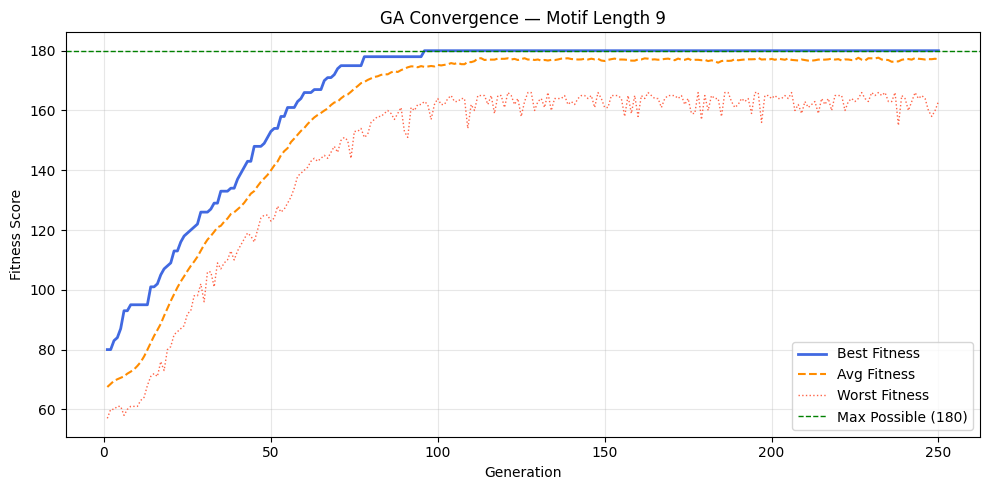

In [15]:
sequences = read_txt_and_return_lines("9_char_seq.txt") 

POP_SIZE = 300
NUM_GENERATIONS = 250
TOURNAMENT_SIZE = 2
MUTATION_RATE = 0.3
ELITE_COUNT = 2
MOTIF_LENGTH = 9

population = initialize_population(POP_SIZE, sequences, MOTIF_LENGTH)
best_chromosome, best_fitness, history = run_ga_with_history(
    population, sequences, MOTIF_LENGTH, NUM_GENERATIONS,
    TOURNAMENT_SIZE, MUTATION_RATE, ELITE_COUNT
)

print(f"Best fitness: {best_fitness}/{MOTIF_LENGTH * 20}")
print(f"Best chromosome: {best_chromosome}")

best_motifs = [seq[pos: pos + MOTIF_LENGTH] for seq, pos in zip(sequences, best_chromosome)]
for motif in best_motifs:
    print(motif)

plot_convergence(history, MOTIF_LENGTH, NUM_GENERATIONS, save_path="convergence.png")